                                       EXPLORATORY DATA ANALYSIS - BLINKIT

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\appuv\Desktop\a bli\data\raw\BlinkIT Grocery Data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Total Sales                8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [3]:
df.head(5)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Total Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [4]:
df.describe()

,Outlet Establishment Year,Item Visibility,Item Weight,Total Sales,Rating
count,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,2010.831867,0.066132,12.857645,140.992782,3.965857
std,8.371760,0.051598,4.643456,62.275067,0.605651
min,1998.000000,0.000000,4.555000,31.290000,1.000000
25%,2000.000000,0.026989,8.773750,93.826500,4.000000
50%,2012.000000,0.053931,12.600000,143.012800,4.000000
75%,2017.000000,0.094585,16.850000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


In [5]:
df.shape

(8523, 12)

In [6]:
df.isnull().sum()

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Total Sales                     0
Rating                          0
dtype: int64

There are 1463 missing item in Total Weight


In [7]:
df['Item Type'].value_counts()

Item Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

In [8]:
nulls_by_type = df.groupby('Item Type')['Item Weight'].apply(lambda x: x.isnull().sum()).sort_values(ascending=False)

print("Missing Item Weight by Item Type:\n", nulls_by_type)
print("\nMissing % by Item Type:\n", (nulls_by_type / df['Item Type'].value_counts() * 100).round(2))

Missing Item Weight by Item Type:
 Item Type
Fruits and Vegetables    213
Snack Foods              212
Household                151
Frozen Foods             138
Dairy                    116
Baking Goods             112
Canned                   110
Health and Hygiene        90
Meat                      88
Soft Drinks               71
Breads                    47
Others                    32
Hard Drinks               31
Breakfast                 21
Starchy Foods             18
Seafood                   13
Name: Item Weight, dtype: int64

Missing % by Item Type:
 Item Type
Baking Goods             17.28
Breads                   18.73
Breakfast                19.09
Canned                   16.95
Dairy                    17.01
Frozen Foods             16.12
Fruits and Vegetables    17.29
Hard Drinks              14.49
Health and Hygiene       17.31
Household                16.59
Meat                     20.71
Others                   18.93
Seafood                  20.31
Snack Foods         

Finding Missing Item Weight by Grouping Item Type
Insight: Data quality varies by category
Meat & Seafood have ~20% missing weight vs Starchy Foods only 12%# 

In [9]:
df['Item Weight'] = df.groupby('Item Type')['Item Weight'].transform(
    lambda x: x.fillna(x.median())
)
df.isnull().sum()

Item Fat Content             0
Item Identifier              0
Item Type                    0
Outlet Establishment Year    0
Outlet Identifier            0
Outlet Location Type         0
Outlet Size                  0
Outlet Type                  0
Item Visibility              0
Item Weight                  0
Total Sales                  0
Rating                       0
dtype: int64

Instead of using overall median, missing weights were filled using median weight of the same `Item Type`. 
This preserves category-specific patterns.

In [10]:
df['Item Fat Content'].value_counts()

Item Fat Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [11]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'LF':'Low Fat', 'reg':'Regular', 'low fat':'Low Fat'})
df['Item Fat Content'].value_counts()

Item Fat Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

In [12]:
print(df.columns.tolist())

['Item Fat Content', 'Item Identifier', 'Item Type', 'Outlet Establishment Year', 'Outlet Identifier', 'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility', 'Item Weight', 'Total Sales', 'Rating']


C:\Users\appuv\AppData\Local\Temp\ipykernel_27976\2138172209.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Item Type', y='Item Weight', data=df, palette='Set2')


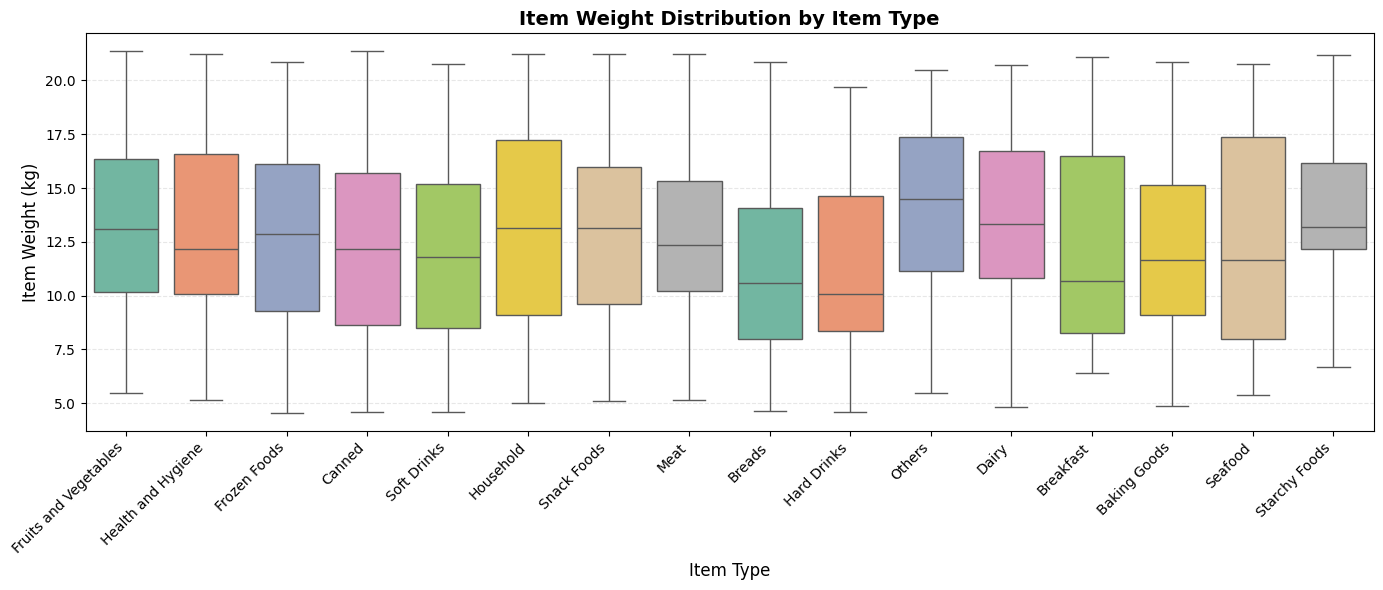

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.boxplot(x='Item Type', y='Item Weight', data=df, palette='Set2')

plt.title('Item Weight Distribution by Item Type', fontsize=14, fontweight='bold')
plt.xlabel('Item Type', fontsize=12)
plt.ylabel('Item Weight (kg)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Observations:No outliers: Boxplot confirms IQR result - 0 outliers detected.
All data points fall within whiskers.
Category-wise pattern: Household and Health and Hygiene show highest median weight, while Soft Drinks and Snack Foods have lowest median weight. 

KPI's Requirements

In [14]:
KPIs = df.agg({
    'Total Sales': ['sum', 'mean', 'count'],
    'Rating': 'mean'
})


In [15]:
print("KPI Metrics:")
print(KPIs.round(2))

KPI Metrics:
       Total Sales  Rating
sum     1201681.48     NaN
mean        140.99    3.97
count      8523.00     NaN


                                               CHARTS REQUIREMENTS


                                              Total Sales by Fat Content

In [16]:
sales_by_fat_content = df.groupby('Item Fat Content').agg({'Total Sales':['sum','mean','count'],'Rating': 'mean'}).reset_index()
sales_by_fat_content.columns = ['Item Fat Content', 'Total Sales Sum', 'Total Sales Mean', 'Total Sales Count','Rating Mean']

C:\Users\appuv\AppData\Local\Temp\ipykernel_27976\1574433188.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Item Fat Content', y='Total Sales Sum', data=sales_by_fat_content, palette='viridis')


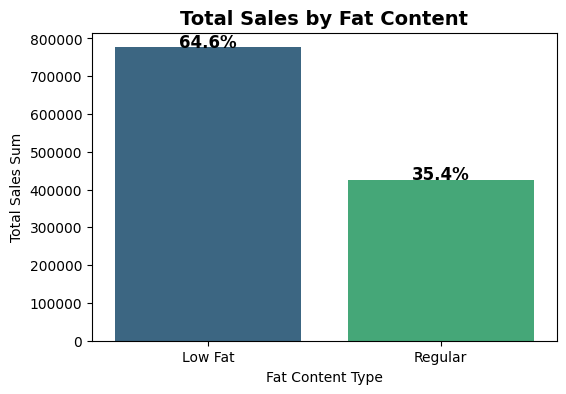

In [45]:

plt.figure(figsize=(6,4))
sns.barplot(x='Item Fat Content', y='Total Sales Sum', data=sales_by_fat_content, palette='viridis')
plt.title('Total Sales by Fat Content', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales Sum')
plt.xlabel('Fat Content Type')

# Add % labels on top of bars
for i, v in enumerate(sales_by_fat_content['Total Sales Sum']):
    pct = v / sales_by_fat_content['Total Sales Sum'].sum() * 100
    plt.text(i, v + 500, f'{pct:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.show()

Low Fat dominates sales: 65% of total sales come from Low Fat items vs only 35% from Regular.  Almost 2x difference.  Consumer preference shift: Customers are clearly choosing health-conscious options. Even if Regular items exist, Low Fat is selling more volume/value.

                                      Total Sales by Item type

In [19]:
sales_by_item_type = df.groupby('Item Type').agg({'Total Sales':['sum','mean','count'],'Rating': 'mean'}).sort_values(('Total Sales', 'sum'),ascending = False).reset_index()
sales_by_item_type.columns = ['Item Type', 'Total Sales Sum', 'Total Sales Mean', 'Total Sales Count','Rating Mean']

In [21]:
Sales_by_type = df.groupby('Item Type')['Total Sales'].sum().sort_values(ascending=False)

In [22]:
Sales_by_type

Item Type
Fruits and Vegetables    178124.0810
Snack Foods              175433.9204
Household                135976.5254
Frozen Foods             118558.8814
Dairy                    101276.4596
Canned                    90706.7270
Baking Goods              81894.7364
Health and Hygiene        68025.8388
Meat                      59449.8638
Soft Drinks               58514.1650
Breads                    35379.1198
Hard Drinks               29334.6766
Others                    22451.8916
Starchy Foods             21880.0274
Breakfast                 15596.6966
Seafood                    9077.8700
Name: Total Sales, dtype: float64

C:\Users\appuv\AppData\Local\Temp\ipykernel_27976\3616526269.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total Sales Sum', y='Item Type', data=sales_by_itemtype_sorted, palette='mako')


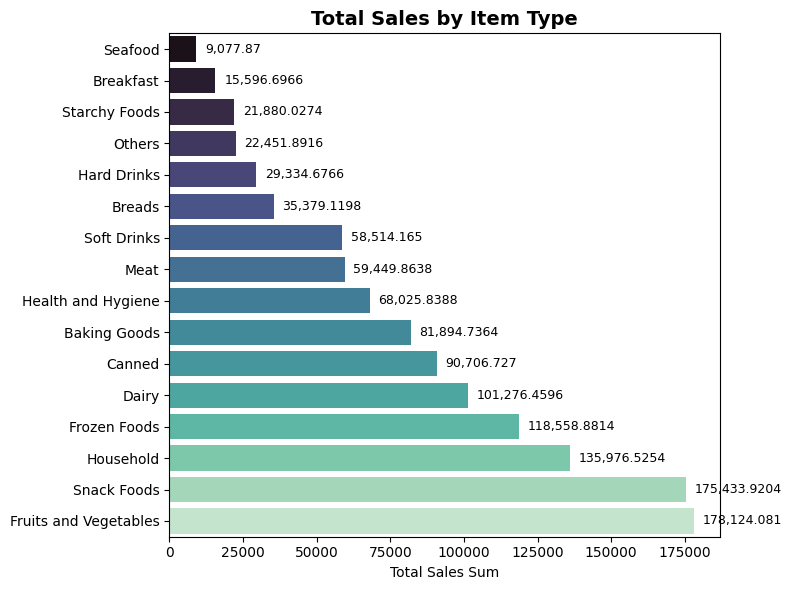

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort data first so biggest bar is on top
sales_by_itemtype_sorted = sales_by_item_type.sort_values('Total Sales Sum', ascending=True)

plt.figure(figsize=(8,6))
sns.barplot(x='Total Sales Sum', y='Item Type', data=sales_by_itemtype_sorted, palette='mako')

plt.title('Total Sales by Item Type', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales Sum')
plt.ylabel('')

# Add value labels
for i, v in enumerate(sales_by_itemtype_sorted['Total Sales Sum']):
    plt.text(v + 3000, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Top 3 revenue drivers: Fruits and Vegetables: 178,124 - #1 sellerSnack Foods: 175,434 - almost same as #1 Household: 135,977 - 3rd place
These 3 alone = ∼49% of all sales. 
Worst performers: Seafood: 9,078 - lowest by far, ∼20x less than FruitsBreakfast: 15,597 Starchy Foods: 21,880
Low sales = low demand or low stock/visibility.


                                   Fat Content by Outlet for Total Sales

In [24]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Total Sales', 'Rating'],
      dtype='object')

In [25]:
grouped = (
    df.groupby(['Outlet Location Type', 'Item Fat Content'])['Total Sales'].sum()
      .unstack()
      .reset_index()
)
grouped.head()


Item Fat Content,Outlet Location Type,Low Fat,Regular
0,Tier 1,215047.9126,121349.8994
1,Tier 2,254464.7734,138685.8682
2,Tier 3,306806.9924,165326.0348


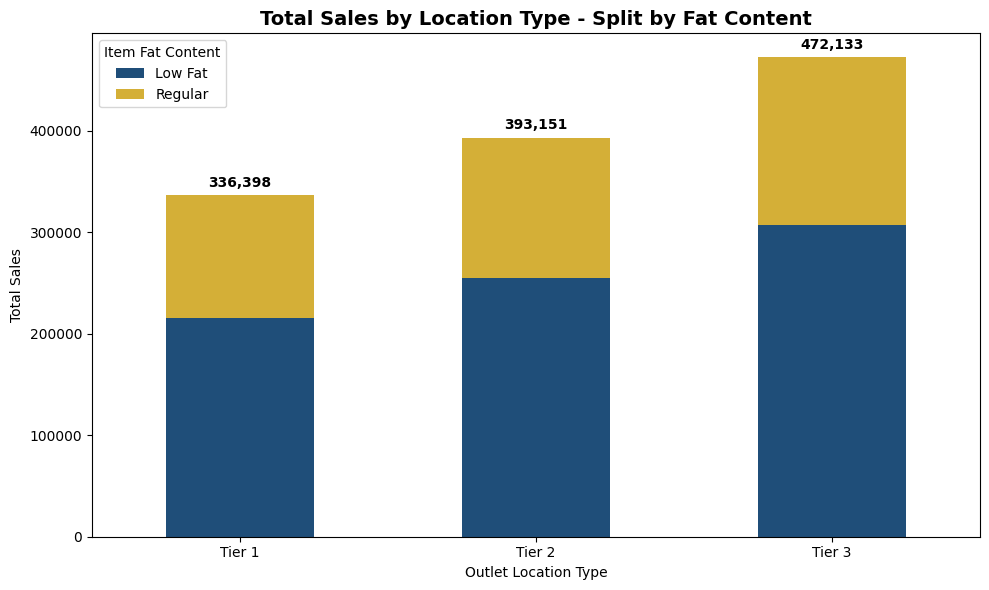

In [50]:
import matplotlib.pyplot as plt

# Reset index so Outlet Location Type becomes column again
grouped_clean = grouped.reset_index()

# Plot stacked bar
ax = grouped_clean.plot(kind='bar', stacked=True, figsize=(10,6), 
                        x='Outlet Location Type', 
                        y=['Low Fat', 'Regular'],  # Use your actual column names
                        color=['#1F4E79', '#D4AF37'])  # Navy + Gold

plt.title('Total Sales by Location Type - Split by Fat Content', fontsize=14, fontweight='bold')
plt.xlabel('Outlet Location Type')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

# Add total labels - now this will work
totals = grouped_clean[['Low Fat', 'Regular']].sum(axis=1)
for i, v in enumerate(totals):
    ax.text(i, v + 8000, f'{v:,.0f}', ha='center', fontweight='bold')

plt.legend(title='Item Fat Content', loc='upper left')
plt.tight_layout()
plt.show()

Tier 3 generates 40% higher sales than Tier 1 = 472K vs 336K. But Low Fat:Regular ratio stays locked at ∼64:36 across all tiers. Location drives volume, not customer preference. Health trend isn't location-dependent.

Low Fat contributes 65% of revenue in every tier = 215K, 253K, 307K respectively. Tier 3 alone adds 92K extra Low Fat sales vs Tier 1. Business impact: 1 Tier 3 store = 1.4 Tier 1 stores in revenue.

                                         Total Sales by Outlet Establishment


In [27]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Total Sales', 'Rating'],
      dtype='object')

In [28]:
Total_Sales_by_Outlet_Establishment = df.groupby('Outlet Establishment Year')['Total Sales'].sum().sort_index()

In [29]:
Total_Sales_by_Outlet_Establishment

Outlet Establishment Year
1998    204522.2570
2000    131809.0156
2010    132113.3698
2011     78131.5646
2012    130476.8598
2015    130942.7782
2017    133103.9070
2020    129103.9564
2022    131477.7724
Name: Total Sales, dtype: float64

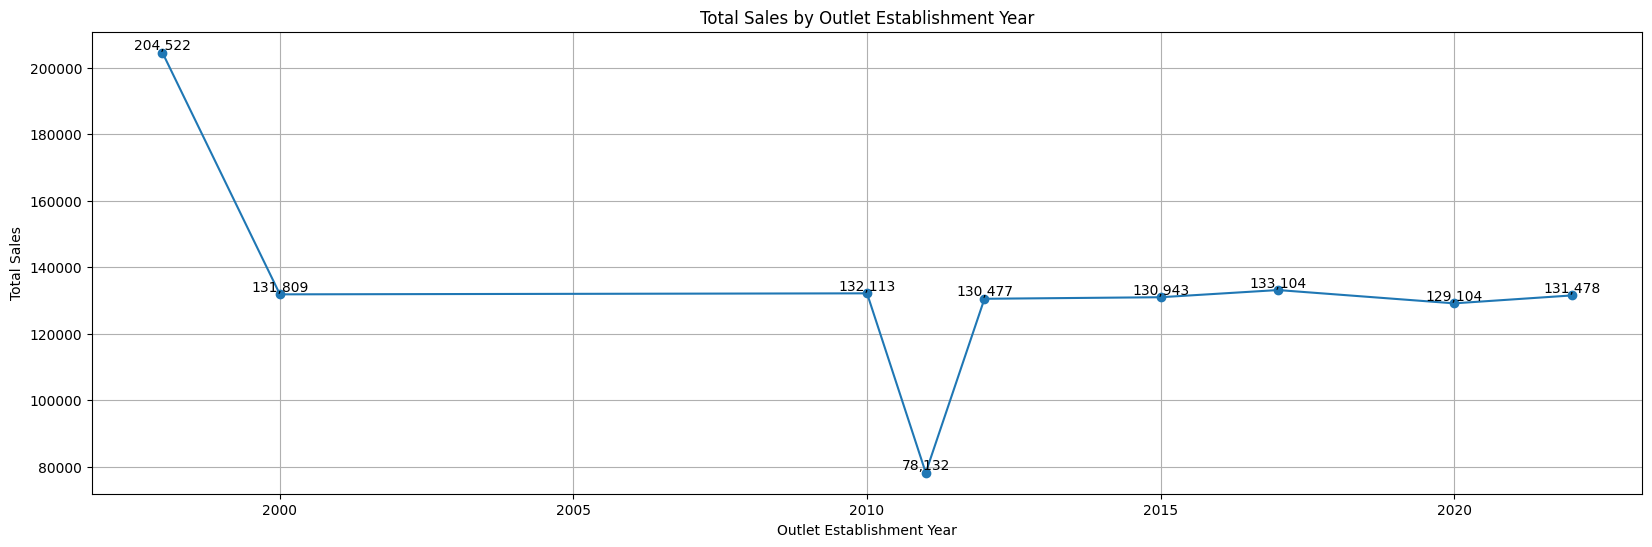

In [30]:
plt.figure(figsize=(20,6))
plt.plot(Total_Sales_by_Outlet_Establishment.index, Total_Sales_by_Outlet_Establishment.values, marker='o')
plt.title('Total Sales by Outlet Establishment Year')
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
for year, sales in zip(Total_Sales_by_Outlet_Establishment.index, Total_Sales_by_Outlet_Establishment.values):
    plt.text(year, sales, f'{sales:,.0f}', ha='center', va='bottom')
plt.grid()
plt.show()




Oldest stores = highest sales: Stores established ∼1998 did 204,522 sales. That’s the peak. Older stores have loyal customers + prime locations.Sharp drop for new stores: ∼2011 establishment year shows only 78,852 sales. That’s the lowest point - ∼62% drop from 1998 stores. Newer stores still building customer base.Stabilization after 2012: From 2012 to 2022, sales stay flat ∼130k-134k. No major growth/decline. Mature stores perform consistently.

                                          Percentage of Sales by Outlet Size


In [31]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Total Sales', 'Rating'],
      dtype='object')

In [32]:
Total_Sales_by_Outlet_size = df.groupby('Outlet Size')['Total Sales'].sum()

In [33]:
Total_Sales_by_Outlet_size

Outlet Size
High      248991.5840
Medium    507895.7284
Small     444794.1684
Name: Total Sales, dtype: float64

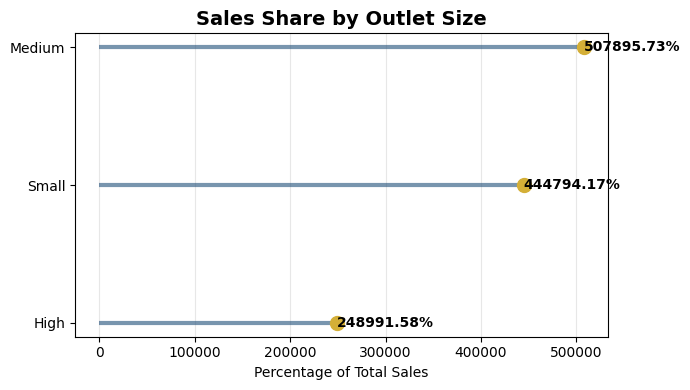

In [53]:
import matplotlib.pyplot as plt

df = Total_Sales_by_Outlet_size.sort_values(ascending=True)

plt.figure(figsize=(7,4))
plt.hlines(y=df.index, xmin=0, xmax=df.values, color='#1F4E79', alpha=0.6, linewidth=3)
plt.plot(df.values, df.index, "o", markersize=10, color='#D4AF37')


for i, v in enumerate(df.values):
    plt.text(v + 0.5, i, f'{v:.2f}%', va='center', fontweight='bold')  # .2f

plt.title('Sales Share by Outlet Size', fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Total Sales')
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Medium outlets drive 42.3% sales despite not being largest format. Small outlets punch above weight at 37% with less space. High size underperforms at 20.7% - suggests diseconomies of scale: higher rent/staff cost not offset by footfall.

79% of revenue comes from Medium+Small formats. Expansion should prioritize Medium stores for efficiency. Audit High-size outlets - either convert format or optimize layout to match Medium store productivity.

                                         Sales by Outlet Location

In [35]:
Total_Sales_by_Outlet_location = df.groupby('Outlet Location Type')['Total Sales'].sum().sort_values(ascending=False).reset_index()

In [36]:
Total_Sales_by_Outlet_location

,Outlet Location Type,Total Sales
0,Tier 3,472133.0272
1,Tier 2,393150.6416
2,Tier 1,336397.8120


In [37]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Total Sales', 'Rating'],
      dtype='object')

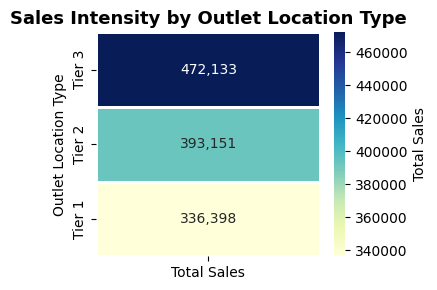

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


df_heat = Total_Sales_by_Outlet_location.set_index('Outlet Location Type')
df_heat.columns = ['Total Sales']  

plt.figure(figsize=(4,3))
ax = sns.heatmap(df_heat, annot=True, fmt=',.0f', cmap='YlGnBu', 
                 cbar_kws={'label': 'Total Sales'}, linewidths=1, linecolor='white')

plt.title('Sales Intensity by Outlet Location Type', fontsize=13, fontweight='bold')
plt.xlabel('')
plt.ylabel('Outlet Location Type')
plt.tight_layout()
plt.show()

Clear hierarchy: Tier 3 > Tier 2 > Tier 1. No exceptions. 
Tier 3: 472,133 | Tier 2: 393,151 | Tier 1: 336,398Tier 3 advantage: Tier 3 stores make ∼40% more than Tier 1 stores. 472k vs 336k. That's huge.Consistent gap: ∼79k difference between each tier. Tier 3-Tier 2 = 78,982. Tier 2-Tier 1 = 56,753. Tier 3 stores are outperforming across the board.

In [39]:
Fat_Content_by_Outlet_for_Total_Sales =  df.groupby(['Outlet Location Type', 'Item Fat Content']).agg({'Total Sales':['sum','mean','count'],'Rating': 'mean'}).unstack().reset_index()
Fat_Content_by_Outlet_for_Total_Sales.head()

Outlet Location Type  Total Sales                           \
                                               sum                     mean   
Item Fat Content                           Low Fat      Regular     Low Fat   
0                              Tier 1  215047.9126  121349.8994  139.641502   
1                              Tier 2  254464.7734  138685.8682  140.665989   
2                              Tier 3  306806.9924  165326.0348  141.516140   

                                                Rating            
                               count              mean            
Item Fat Content     Regular Low Fat Regular   Low Fat   Regular  
0                 143.101296    1540     848  3.980000  3.971698  
1                 142.096176    1809     976  3.967828  3.951230  
2                 139.869742    2168    1182  3.955258  3.971743

In [40]:
#Downloading CSV file for SQl Queries without SQL connect

df.to_csv('Blinkit_Grocery_cleaned.csv', index=False) 

In [41]:
from dotenv import load_dotenv
import os
load_dotenv()


True

In [42]:
import os
os.getcwd()

'C:\\Users\\appuv\\Desktop\\a bli\\notebooks'

In [43]:
from sqlalchemy import create_engine

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

# PostgreSQL connection
engine = create_engine(
    f"postgresql+psycopg2://"
    f"{DB_USER}:{DB_PASSWORD}@"
    f"{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# Upload dataframe
df.to_sql(
    name="Blinkit Sales",
    con=engine,
    if_exists="replace",
    index=False,
    method="multi"
)

print("Data successfully loaded into PostgreSQL.")

Data successfully loaded into PostgreSQL.
